# PPO Implementation

In [1]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque
from torch.distributions import Categorical

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
class Actor(nn.Module):
    """
    Policy network π(a | s; θ).
    Outputs a categorical distribution over discrete actions.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> Categorical:
        logits = self.net(x)
        return Categorical(logits=logits)

    def log_prob(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.forward(x).log_prob(a)
            
    def policy_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        policy = np.zeros(env.n_states, dtype=np.int8)
        for state in states:
            state_vec = state.get_state_feature_vec(env.n_states)
            state_vec = torch.Tensor(state_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                action_probs = self.forward(state_vec).probs
                policy[state.idx] = torch.argmax(action_probs, dim=-1).item()
        return policy

In [3]:
class Critic(nn.Module):
    """
    state-value network V(s; φ).
    Outputs one scalar per discrete action → index by chosen action.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns Q-values for all actions, shape (batch, act_dim)."""
        return self.net(x)
    def v_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        V = np.zeros(env.n_states, dtype=np.float32)
        for state in states:
            state_feat_vec = state.get_state_feature_vec(env.n_states)
            state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                v_value = self.forward(state_feat_vec).squeeze(1)
            V[state.idx] = v_value.item()
        return V

In [9]:
class PPOAgent:
    def __init__(self, env, actor, critic, lr_actor, lr_critic, gamma,
                 clip_eps=0.2, gae_lambda=0.95, n_epochs=4, batch_size=32):
        self.env        = env
        self.actor      = actor
        self.critic     = critic
        self.opt_actor  = optim.Adam(self.actor.parameters(),  lr=lr_actor, eps=1e-5)  # FIX 1: eps=1e-5 prevents Adam denominator collapse
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=lr_critic, eps=1e-5)
        self.gamma      = gamma
        self.clip_eps   = clip_eps
        self.gae_lambda = gae_lambda
        self.n_epochs   = n_epochs
        self.batch_size = batch_size

    def compute_gae(self, rewards, values, next_values, masks):
        advantages = []
        gae = 0.0
        for r, v, v_next, mask in zip(
                reversed(rewards), reversed(values),
                reversed(next_values), reversed(masks)):
            delta = r + self.gamma * v_next * mask - v
            gae   = delta + self.gamma * self.gae_lambda * mask * gae
            advantages.insert(0, gae)

        advantages    = torch.tensor(advantages, dtype=torch.float32)
        value_targets = advantages + torch.tensor(values, dtype=torch.float32)

        # FIX 2: only normalise when we have >1 sample (avoids std=0 warning)
        if advantages.numel() > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        return advantages, value_targets

    def ppo_update(self, states, actions, old_log_probs, advantages, value_targets):
        T = states.shape[0]
        total_actor_loss  = 0.0
        total_critic_loss = 0.0
        total_updates     = 0

        for _ in range(self.n_epochs):
            perm = torch.randperm(T)
            for start in range(0, T, self.batch_size):
                idx  = perm[start : start + self.batch_size]
                s_b  = states[idx]
                a_b  = actions[idx]
                olp_b = old_log_probs[idx]
                adv_b = advantages[idx]
                vt_b  = value_targets[idx]

                # FIX 3: guard against NaN logits before computing loss
                new_log_probs = self.actor.log_prob(s_b, a_b)
                if torch.isnan(new_log_probs).any():
                    print("[PPO] NaN in log_probs — skipping minibatch")
                    continue

                ratio          = torch.exp(new_log_probs - olp_b)
                surr_unclipped = ratio * adv_b
                surr_clipped   = torch.clamp(ratio,
                                             1 - self.clip_eps,
                                             1 + self.clip_eps) * adv_b
                actor_loss = -torch.min(surr_unclipped, surr_clipped).mean()

                self.opt_actor.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)   # FIX 4: tighter clip (was 1.0)
                self.opt_actor.step()

                v_pred      = self.critic(s_b).squeeze(-1)
                critic_loss = F.mse_loss(v_pred, vt_b)

                self.opt_critic.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)  # FIX 4: tighter clip
                self.opt_critic.step()

                total_actor_loss  += actor_loss.item()
                total_critic_loss += critic_loss.item()
                total_updates     += 1

        if total_updates == 0:
            return 0.0, 0.0
        return total_actor_loss / total_updates, total_critic_loss / total_updates

    def update_on_rollout(self, rollout):
        s_list, a_list, r_list, ns_list, done_list = zip(*rollout)

        states      = torch.FloatTensor(np.array(s_list))
        actions     = torch.LongTensor(a_list)
        next_states = torch.FloatTensor(np.array(ns_list))
        masks       = torch.FloatTensor([0.0 if d else 1.0 for d in done_list])

        with torch.no_grad():
            values        = self.critic(states).squeeze(-1).tolist()
            next_values   = self.critic(next_states).squeeze(-1).tolist()
            old_log_probs = self.actor.log_prob(states, actions).detach()

        advantages, value_targets = self.compute_gae(
            list(r_list), values, next_values, masks.tolist())

        a_loss, c_loss = self.ppo_update(
            states, actions, old_log_probs, advantages, value_targets)

        return a_loss, c_loss

    @torch.no_grad()
    def sample_action(self, s, greedy=False):
        s    = torch.FloatTensor(s).unsqueeze(0)
        dist = self.actor(s)
        if greedy:
            return dist.probs.argmax(dim=-1).item()
        return dist.sample().item()

In [32]:
def train(env, n_episodes, gamma=0.99, lr_actor=1e-4, lr_critic=1e-4,
          clip_eps=0.2, gae_lambda=0.95, n_epochs=4, batch_size=32):

    actor  = Actor(env.n_states, env.n_actions)
    critic = Critic(env.n_states, env.n_actions)
    agent  = PPOAgent(env, actor, critic, lr_actor, lr_critic, gamma,
                      clip_eps=clip_eps, gae_lambda=gae_lambda,
                      n_epochs=n_epochs, batch_size=batch_size)

    trajectory_histories = []
    policy_histories     = []
    V_histories          = []

    for episode_idx in range(n_episodes):
        s       = env.find('S')
        s_feat  = s.get_state_feature_vec(env.n_states)
        rollout = []          # collect full episode before updating
        G       = 0.0
        trajectory = []
        while True:
            a      = agent.sample_action(s_feat)
            result = env.step(s, a)

            r             = result["reward"]
            next_s        = result["new_state"]
            next_s_feat   = next_s.get_state_feature_vec(env.n_states)
            is_terminated = result["is_terminated"]

            rollout.append((s_feat, a, r, next_s_feat, is_terminated))
            trajectory.append(s.coord)


            s      = next_s
            s_feat = next_s_feat
            G     += r
            
            if is_terminated:
                break

        trajectory_histories.append(trajectory)
        
        # ── Single PPO update per episode ── #
        a_loss, c_loss = agent.update_on_rollout(rollout)


        if episode_idx % 500 == 0:
            print(f"[{episode_idx}] actor_loss={a_loss:.4f}  "
                  f"critic_loss={c_loss:.4f}  G={G:.2f}")
            policy_histories.append(agent.actor.policy_table(env))
            V_histories.append(agent.critic.v_table(env))

    return policy_histories, V_histories, trajectory_histories

In [33]:
# lake_grid = [["G", "H", "F", "F"],
#              ["F", "F", "F", "F"],
#              ["F", "F", "H", "F"],
#              ["F", "H", "S", "F"]]

lake_grid = [["F", "F", "S", "F", "H"],
             ["F", "F", "H", "F", "F"],
             ["F", "F", "F", "G", "F"],
             ["F", "H", "F", "F", "F"],
             ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 1,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [34]:
policy_histories, v_histories, trajectory_histories = train(frozen_lake, n_episodes=5000)

[0] actor_loss=-0.0016  critic_loss=0.0008  G=0.00
[500] actor_loss=-0.0017  critic_loss=0.0009  G=0.00
[1000] actor_loss=-0.0014  critic_loss=0.0688  G=0.00
[1500] actor_loss=-0.0027  critic_loss=0.3968  G=1.00
[2000] actor_loss=-0.0000  critic_loss=0.1833  G=0.00
[2500] actor_loss=0.1057  critic_loss=0.0199  G=1.00
[3000] actor_loss=-0.0004  critic_loss=0.0905  G=0.00
[3500] actor_loss=-0.0007  critic_loss=0.0850  G=0.00
[4000] actor_loss=-0.0001  critic_loss=0.0731  G=0.00
[4500] actor_loss=-0.0000  critic_loss=0.0432  G=0.00


In [35]:
policy = policy_histories[-1]
policy

array([1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 3, 1, 1, 1,
       2, 1, 3], dtype=int8)

In [36]:
trajectory_histories[0]

[(0, 2),
 (0, 1),
 (1, 1),
 (1, 0),
 (1, 1),
 (2, 1),
 (2, 2),
 (2, 1),
 (1, 1),
 (2, 1),
 (2, 2),
 (3, 2),
 (2, 2),
 (3, 2)]

# Render policy

In [37]:
import pandas as pd
from IPython.display import display

In [38]:
len(trajectory_histories)

5000

In [39]:
trajectory_histories[3]

[(0, 2),
 (0, 1),
 (0, 2),
 (0, 2),
 (0, 2),
 (0, 2),
 (0, 3),
 (1, 3),
 (0, 3),
 (0, 2)]

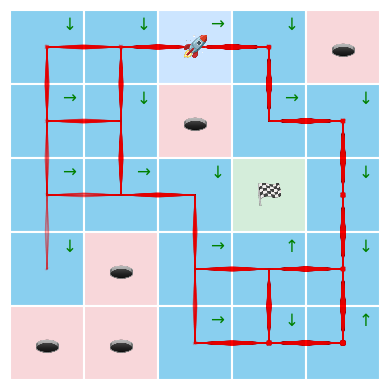

In [40]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)